# ch271 — Data and Measurement

## 1. What Is Data?

Data is a record of measurements. Every measurement is a number (or a category) attached to a unit, a time, and a procedure. Remove any of those components and the number becomes ambiguous.

The statement "user engagement is 42" means nothing. "42 seconds of average session duration measured on mobile users between 09:00–17:00 UTC on 2024-01-15" means something.

Before you touch a dataset statistically, you must answer:
1. What was measured?
2. How was it measured?
3. When and on whom?
4. What can go wrong with this measurement?

These are not philosophical questions. They determine which statistical procedures are valid.

---

## 2. Scales of Measurement

Stanley Stevens (1946) identified four scales. They determine which arithmetic operations are meaningful.

| Scale | Operations | Examples |
|---|---|---|
| **Nominal** | =, ≠ | Category, color, user ID |
| **Ordinal** | =, ≠, <, > | Survey rating (1–5), rank |
| **Interval** | +, − | Temperature in °C, calendar year |
| **Ratio** | +, −, ×, ÷ | Height, revenue, time elapsed |

Computing a mean on ordinal data is technically invalid (though widely done). Saying "Monday is twice as long as Sunday" violates ratio semantics.

*(Concepts of ratio and proportion introduced in ch034 — Ratios and Proportions)*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate why scale matters: computing mean on ordinal data
# Survey: satisfaction (1=very dissatisfied, 5=very satisfied)
responses = np.array([1, 2, 2, 3, 3, 3, 4, 4, 5, 5])

# Arithmetic mean assumes equal spacing between categories
mean_val = responses.mean()
median_val = np.median(responses)

print(f"Ordinal scale: {responses}")
print(f"Mean   = {mean_val:.2f}  (assumes 4−3 = 3−2 = 2−1 — is that true?)")
print(f"Median = {median_val:.1f}  (only requires rank ordering — always valid)")
print()

# Now ratio scale: revenue in dollars
revenue = np.array([100, 200, 200, 300, 300, 300, 400, 400, 500, 500])
print(f"Ratio scale: revenue = {revenue}")
print(f"Mean = {revenue.mean():.0f} — arithmetic meaningful because $400 is twice $200")
print(f"Ratio 400/200 = {400/200:.1f}x — interpretable")

# Temperature: interval, not ratio
temp_c = np.array([0, 10, 20, 30])
print()
print(f"Temperature °C: {temp_c}")
print(f"30°C / 10°C = {30/10}x — NOT meaningful (0°C is not 'no temperature')")
print(f"30°F / 10°F = ? — even more meaningless")

Ordinal scale: [1 2 2 3 3 3 4 4 5 5]
Mean   = 3.20  (assumes 4−3 = 3−2 = 2−1 — is that true?)
Median = 3.0  (only requires rank ordering — always valid)

Ratio scale: revenue = [100 200 200 300 300 300 400 400 500 500]
Mean = 320 — arithmetic meaningful because $400 is twice $200
Ratio 400/200 = 2.0x — interpretable

Temperature °C: [ 0 10 20 30]
30°C / 10°C = 3.0x — NOT meaningful (0°C is not 'no temperature')
30°F / 10°F = ? — even more meaningless


## 3. Types of Variables

Within those four scales, practical data science uses a refined taxonomy:

- **Continuous**: can take any value in an interval (height, price, temperature)
- **Discrete**: countable distinct values (number of items, clicks)
- **Binary**: exactly two values (purchased/not, alive/dead)
- **Categorical / nominal**: unordered labels (country, browser type)
- **Ordinal**: ordered categories (satisfaction score, education level)
- **Count**: non-negative integers, often Poisson-distributed *(introduced in ch252)*

The type of a variable determines the appropriate:
- Summary statistic (mean vs median vs mode)
- Visualization (histogram vs bar chart vs scatter)
- Statistical test (t-test vs chi-squared vs Mann-Whitney)
- Model (linear regression vs logistic regression vs Poisson regression)

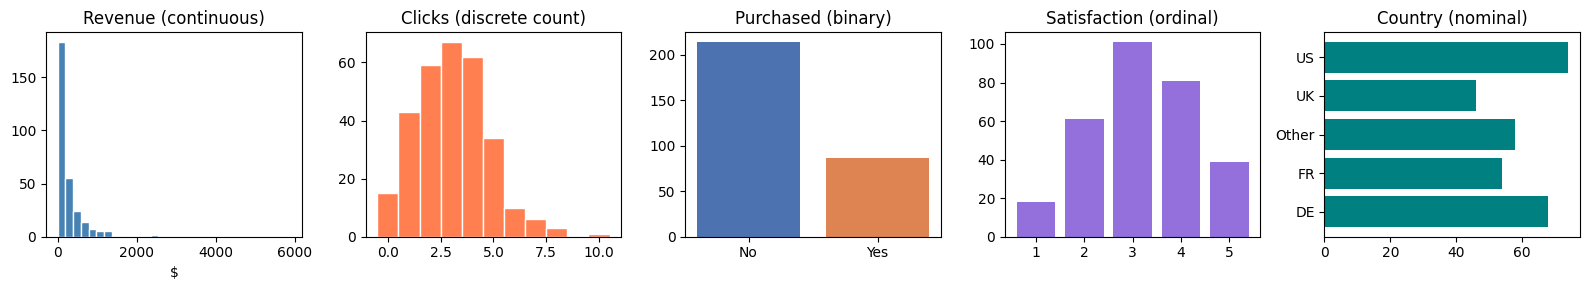

In [2]:
rng = np.random.default_rng(0)
n = 300

data = {
    'revenue':      rng.lognormal(mean=5, sigma=1.2, size=n),      # continuous, right-skewed
    'clicks':       rng.poisson(lam=3, size=n),                     # discrete count
    'purchased':    rng.binomial(1, 0.3, size=n),                   # binary
    'satisfaction': rng.choice([1,2,3,4,5], size=n,                 # ordinal
                               p=[0.05,0.15,0.3,0.35,0.15]),
    'country':      rng.choice(['US','UK','DE','FR','Other'], n),    # nominal
}

fig, axes = plt.subplots(1, 5, figsize=(16, 3))

axes[0].hist(data['revenue'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Revenue (continuous)'); axes[0].set_xlabel('$')

axes[1].hist(data['clicks'], bins=range(0, 12), color='coral', edgecolor='white', align='left')
axes[1].set_title('Clicks (discrete count)')

axes[2].bar([0,1], [np.sum(data['purchased']==0), np.sum(data['purchased']==1)],
            color=['#4C72B0','#DD8452'])
axes[2].set_xticks([0,1]); axes[2].set_xticklabels(['No','Yes'])
axes[2].set_title('Purchased (binary)')

vals, counts = np.unique(data['satisfaction'], return_counts=True)
axes[3].bar(vals, counts, color='mediumpurple')
axes[3].set_title('Satisfaction (ordinal)')

countries, counts = np.unique(data['country'], return_counts=True)
axes[4].barh(countries, counts, color='teal')
axes[4].set_title('Country (nominal)')

plt.tight_layout()
plt.show()

## 4. The Measurement Process

A measurement is never perfect. Every observation contains:

$$x_{\text{observed}} = x_{\text{true}} + \epsilon_{\text{systematic}} + \epsilon_{\text{random}}$$

- **Systematic error (bias)**: a consistent directional offset. Calibration error in a sensor, leading survey questions, self-reporting bias.
- **Random error (noise)**: zero-mean fluctuations that average out with enough samples.

This decomposition reappears in ch276 (Bias and Variance), where the same ideas apply to models rather than individual measurements.

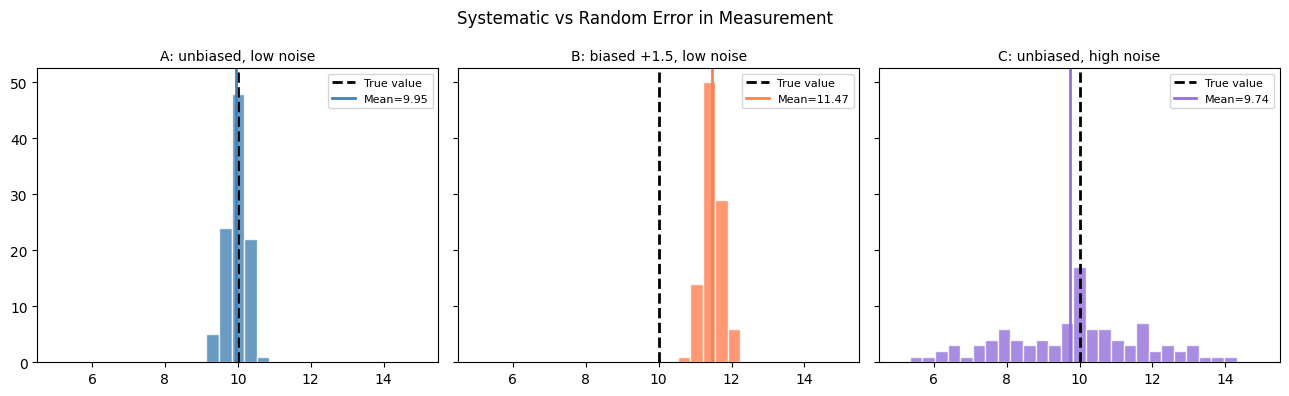

Instrument B: more data cannot fix the bias. The error is structural.
Instrument C: more data will reduce uncertainty — noise averages out.


In [3]:
rng = np.random.default_rng(7)
n_measurements = 100
true_value = 10.0

# Three instruments
instrument_a = true_value + rng.normal(0,   0.3, n_measurements)  # unbiased, low noise
instrument_b = true_value + rng.normal(1.5, 0.3, n_measurements)  # biased +1.5, low noise
instrument_c = true_value + rng.normal(0,   2.0, n_measurements)  # unbiased, high noise

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
bins = np.linspace(5, 15, 30)

for ax, instrument, label, color in zip(
    axes,
    [instrument_a, instrument_b, instrument_c],
    ['A: unbiased, low noise', 'B: biased +1.5, low noise', 'C: unbiased, high noise'],
    ['steelblue', 'coral', 'mediumpurple']
):
    ax.hist(instrument, bins=bins, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(true_value, color='black', ls='--', lw=2, label='True value')
    ax.axvline(instrument.mean(), color=color, ls='-', lw=2, label=f'Mean={instrument.mean():.2f}')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Systematic vs Random Error in Measurement', fontsize=12)
plt.tight_layout()
plt.show()

print("Instrument B: more data cannot fix the bias. The error is structural.")
print("Instrument C: more data will reduce uncertainty — noise averages out.")

## 5. Units and Dimensional Analysis

Numbers without units are incomplete. Before modeling:
- Record units for every variable
- Check that operations are dimensionally consistent
- Track unit transformations explicitly

The Mars Climate Orbiter was lost in 1999 because one subsystem used pound-force·seconds and another used newton-seconds. $125M and a spacecraft, destroyed by a unit error.

In [4]:
# Dimensional analysis: velocity from position and time
position_m   = np.array([0.0, 5.0, 12.0, 21.0, 32.0])  # meters
time_s       = np.array([0.0, 1.0,  2.0,  3.0,  4.0])  # seconds

velocity_ms  = np.diff(position_m) / np.diff(time_s)    # m/s — correct

# What if someone mixed units?
position_km  = position_m / 1000.0  # km
velocity_wrong = np.diff(position_km) / np.diff(time_s) # km/s instead of m/s

print("Correct  velocity (m/s): ", velocity_ms)
print("Wrong    velocity (km/s):", velocity_wrong)
print(f"Ratio: {velocity_ms[0] / velocity_wrong[0]:.0f}x off")
print()
print("Units are part of the data. Treat them as such.")

Correct  velocity (m/s):  [ 5.  7.  9. 11.]
Wrong    velocity (km/s): [0.005 0.007 0.009 0.011]
Ratio: 1000x off

Units are part of the data. Treat them as such.


## 6. Data as a Random Sample

A core assumption of classical statistics: your dataset is a **random sample** from a **population**. Every formula in chapters 273–285 depends on this.

- **Population**: the full set of entities you care about (all users, all transactions)
- **Sample**: the subset you actually have
- **Statistic**: a number computed from the sample (sample mean, sample variance)
- **Parameter**: the corresponding true value in the population (μ, σ²)

Statistics attempts to infer parameters from statistics. The quality of that inference depends entirely on how the sample was collected.

*(ch275 — Sampling explores how sampling method affects inference.)*

## 7. Summary

| Concept | Key Point |
|---|---|
| Scales of measurement | Determine what arithmetic is valid |
| Variable types | Determine appropriate summaries, tests, models |
| Measurement error | Bias is structural; noise decreases with sample size |
| Units | Non-negotiable; track them explicitly |
| Sample vs population | All of classical statistics lives in this gap |

## 8. Exercises

1. A dataset of "customer satisfaction" uses values 1–10. A colleague computes `mean(scores) * 2`. Is this valid? Why or why not?
2. You measure 50 users' session times. The sensor has a known 2-second systematic delay. How does this affect the sample mean? The sample variance?
3. List three variables from a web analytics dataset. For each, state its scale and type.

## 9. What Comes Next

Now that you understand what data is and how it breaks, ch272 addresses the first practical problem: data is almost never clean. Missing values, duplicates, outliers, and encoding errors are the norm, not the exception.

The bias/noise decomposition introduced here will reappear formally in **ch276 — Bias and Variance**, where it applies to model predictions rather than individual sensor readings. The population/sample distinction underpins every inference procedure from ch277 onward.